# Validate Survey-Vote Semantic Matches

Inspect the quality of semantic matches between Eurobarometer survey questions and EU parliament votes.
Use this notebook to tune the similarity threshold.


In [ ]:
import pandas as pd
from IPython.display import display, HTML

matches_df = pd.read_csv("data/matches/survey_vote_matches.csv")
print(f"Total matches: {len(matches_df)}")
print(f"Unique questions matched: {matches_df['question_id'].nunique()}")
print(f"Unique votes matched: {matches_df['vote_id'].nunique()}")
print(f"\nSimilarity score stats:")
matches_df["similarity_score"].describe()


Total matches: 3987
Unique questions matched: 888
Unique votes matched: 493

Similarity score stats:


count    3987.000000
mean        0.562099
std         0.048690
min         0.500011
25%         0.522450
50%         0.549396
75%         0.593574
max         0.789827
Name: similarity_score, dtype: float64

In [ ]:
matches_df[
    matches_df["match_id"]
    == "9cf90113c41010cd39921e02753f08c7c1639921b80a5f585359442897e6a4b8_159684"
]

,question_index,question_text,file_name,vote_id,vote_summary,similarity_score,question_id,match_id
3911,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_541_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3912,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_520_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3913,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_540_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3914,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_503_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3915,0013,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_490_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3916,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_504_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3917,Q2a_1,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_519_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...
3918,0003,Q2a_1 Could you tell me to what extent each of...,Lien_vers_fl_489_volume_B.xlsx,159684,Limited progress in bringing those responsible...,0.501182,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...,9cf90113c41010cd39921e02753f08c7c1639921b80a5f...


## Similarity Score Distribution


<Axes: >

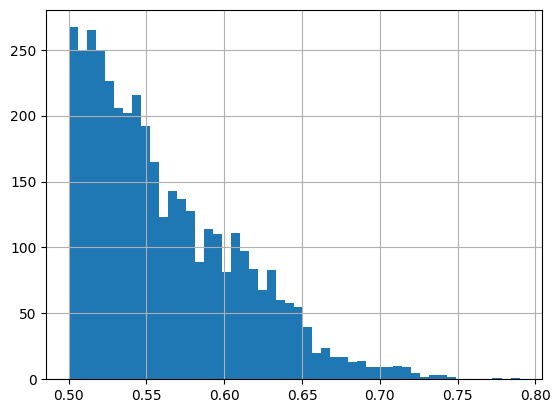

In [4]:
matches_df["similarity_score"].hist(bins=50)


## Inspect Top Matches

Side-by-side view of the best matches to judge quality.


In [5]:
# Show top 20 highest-scoring matches
top_matches = matches_df.head(20)

for _, row in top_matches.iterrows():
    score = row["similarity_score"]
    print("=" * 100)
    print(f"SCORE: {score:.4f}")
    print(f"\n  SURVEY QUESTION ({row['question_id']} | {row['file_name']}):")
    print(f"    {row['question_text']}")
    print(f"\n  VOTE SUMMARY (vote_id={row['vote_id']}):")
    print(f"    {row['vote_summary'][:300]}")
    print()


SCORE: 0.7898

  SURVEY QUESTION (QB7_2 | Lien_vers_SP546_volume_B.xlsx):
    QB7.2. The European Year of Skills is taking place between May 2023 and May 2024. It aims to raise awareness about the need for people to get the right skills for quality jobs and thereby also aims to support companies in addressing skill shortages in Europe. For each of the following statements, tell me if it applies to you? :-You are currently engaging in training to improve your skills

  VOTE SUMMARY (vote_id=153918):
    The European Parliament adopted by 524 votes to 33, with 24 abstentions, a legislative resolution on the proposal for a decision of the European Parliament and of the Council on a European Year of Skills 2023.
The European Parliament's position adopted at first reading under the ordinary legislative

SCORE: 0.7777

  SURVEY QUESTION (QB7_1 | Lien_vers_SP546_volume_B.xlsx):
    QB7.1. The European Year of Skills is taking place between May 2023 and May 2024. It aims to raise awareness abo

## Filter by Threshold

Adjust the threshold below to explore different quality levels.


In [6]:
THRESHOLD = 0.5  # <-- adjust this value

filtered = matches_df[matches_df["similarity_score"] >= THRESHOLD]
print(f"Matches above {THRESHOLD}: {len(filtered)}")
print(f"Unique questions: {filtered['question_id'].nunique()}")
print(f"Unique votes: {filtered['vote_id'].nunique()}")

# Show best match per question (deduplicated view)
best_per_question = filtered.sort_values(
    "similarity_score", ascending=False
).drop_duplicates(subset=["question_id"], keep="first")
print(f"\nQuestions with at least one match: {len(best_per_question)}")
best_per_question[
    ["question_id", "question_text", "vote_id", "vote_summary", "similarity_score"]
].head(20)


Matches above 0.5: 3987
Unique questions: 543
Unique votes: 493

Questions with at least one match: 543


,question_id,question_text,vote_id,vote_summary,similarity_score
0,QB7_2,QB7.2. The European Year of Skills is taking p...,153918,The European Parliament adopted by 524 votes t...,0.789827
1,QB7_1,QB7.1. The European Year of Skills is taking p...,153918,The European Parliament adopted by 524 votes t...,0.777720
2,Q7_1,"Q7_1 For each of the following initiatives, pl...",126261,The European Parliament adopted by 550 votes t...,0.746313
3,Q1_1,Q1_1 Imagine a major crisis affecting [YOUR CO...,157227,Evaluation of the effectiveness of EU and nati...,0.744503
4,Q3_6,Q3_6 To what extent do you agree or disagree w...,134947,The European Parliament adopted by 479 votes t...,0.742232
5,Q4_4,"Q4_4 In fact, all citizens of the EU Member St...",163001,The European Parliament adopted by 437 votes t...,0.741735
7,Q3_4,Q3_4 To what extent do you agree or disagree w...,134947,The European Parliament adopted by 479 votes t...,0.735519
8,Q3_5,Q3_5 To what extent do you agree or disagree w...,134947,The European Parliament adopted by 479 votes t...,0.734950
9,Q10_3,Q10_3 The following statements are about inter...,171271,The European Parliament adopted by 441 votes t...,0.732377
10,Q3_3,Q3_3 To what extent do you agree or disagree w...,134947,The European Parliament adopted by 479 votes t...,0.731862
